In [34]:
import logging, warnings
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import spearmanr, ConstantInputWarning
from tqdm import tqdm
from umap import UMAP
from dtaidistance import dtw, dtw_visualisation as dtwvis
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib
import importlib
import sys

from src.utils import iter_dataset_dirs, load_json
from src.plot_style import apply_plot_style
from src.visualization import plot_mts_corr_density, plot_spi_space_individual, plot_pca, plot_tsne, plot_umap, plot_mts_heatmap

apply_plot_style()
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
warnings.simplefilter("ignore", ConstantInputWarning)


In [35]:
def generate_ar1(T: int, a: float, noise_std: float, seed=None):
    rng = np.random.default_rng(seed)
    X = np.zeros(T)
    for t in range(1, T):
        X[t] = a * X[t-1] + rng.normal(0, noise_std)
    return X

def warp_path(T: int, regime: str = "rebound", *, step: int = 1, p: float = 0.5, p_step: float = 0.5, seed=None) -> np.ndarray:
    """
    Random monotone warping path from (0,0) to (T-1,T-1).

    Regimes
    -------
    "walk"      : fixed step size `step`, uniform random direction.
    "geometric" : step ~ Geometric(p), uniform random direction.
    "rebound"   : step ~ Geometric(p); with probability p_step make an L-shaped
                  RU or UR excursion off the identity, else step diagonally.

    Parameters
    ----------
    T      : series length
    regime : "walk" | "geometric" | "rebound"
    step   : fixed step size  (walk only)
    p      : Geometric distribution parameter  (geometric, rebound)
    p_step : probability of L-shaped excursion per cycle  (rebound only)
    seed   : RNG seed
    """
    rng = np.random.default_rng(seed)
    x, y = 0, 0
    path = [(x, y)]

    if regime in ("walk", "geometric"):
        while x < T - 1 or y < T - 1:
            s = step if regime == "walk" else int(np.clip(rng.geometric(p), 1, T))
            if x >= T - 1:
                y = min(y + s, T - 1)
            elif y >= T - 1:
                x = min(x + s, T - 1)
            elif rng.integers(2) == 0:
                x = min(x + s, T - 1)
            else:
                y = min(y + s, T - 1)
            path.append((x, y))

    elif regime == "rebound":
        while x < T - 1:
            s = int(min(rng.geometric(p), T - 1 - x))
            if rng.uniform() < p_step:
                if rng.integers(2) == 0:  # R then U
                    x += s; path.append((x, y))
                    y += s; path.append((x, y))
                else:                      # U then R
                    y += s; path.append((x, y))
                    x += s; path.append((x, y))
            else:
                x += 1; y += 1
                path.append((x, y))

    else:
        raise ValueError(f"regime must be 'walk', 'geometric', or 'rebound', got {regime!r}")

    return np.asarray(path, dtype=int)

def path_to_mapping(path: np.ndarray, T: int):
    n = np.zeros(T, dtype=int)
    s = np.zeros(T, dtype=float)
    for x, y in path:
        n[y] += 1
        s[y] += x
    m = np.zeros(T, dtype=int)
    for y in range(T):
        m[y] = int(round(s[y] / n[y])) if n[y] > 0 else 0
    m = np.clip(m, 0, T - 1)
    m = np.maximum.accumulate(m)
    return m

def warp_series(X_orig: np.ndarray, mapping: np.ndarray):
    return X_orig[mapping].copy()

def plot_warp(X, X_warp, path, figsize: tuple = (12, 4), title_left: str = "Original vs Warped Time Series", title_right: str = "Warp Path"):
    """Plot original/warped signals and warp path in (t_orig, t_warp) space."""
    X = np.asarray(X)
    X_warp = np.asarray(X_warp)
    path = np.asarray(path)
    if path.ndim != 2 or path.shape[1] != 2:
        raise ValueError("path must be shape (n, 2)")

    T = len(X)
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=300)

    ax = axes[0]
    ax.plot(X, label="Original", color="gray", lw=1.0)
    ax.plot(X_warp, label="Warped", lw=1.0, alpha=0.8, color="royalblue")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$X(t)$")
    ax.set_title(title_left)
    ax.legend()

    ax = axes[1]
    ax.plot([0, T - 1], [0, T - 1], lw=0.75, alpha=0.5, color="gray", label="Identity")
    ax.plot(path[:, 0], path[:, 1], lw=1, alpha=0.8, label="Warp path", color="purple")
    ax.set_xlabel(r"$t_{\mathrm{orig}}$")
    ax.set_ylabel(r"$t_{\mathrm{warp}}$")
    ax.set_title(title_right)
    ax.set_aspect("equal")
    ax.legend()
    fig.tight_layout()
    plt.show()
    return fig, axes

def _to_dtwvis_path(path):
    """Convert path to list-of-tuples format expected by dtw_visualisation."""
    if path is None:
        return None
    if isinstance(path, (int, np.integer)) and int(path) == -1:
        return -1
    arr = np.asarray(path)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("path must be shape (n, 2)")
    return [tuple(map(int, p)) for p in arr]

def compute_dtw(s_orig, s_warp, *, use_c=True, **warping_paths_kwargs):
    """Compute DTW distance, paths matrix, and best path."""
    dtw_dist, paths = dtw.warping_paths(s_orig, s_warp, use_c=use_c, **warping_paths_kwargs)
    return dtw_dist, paths, dtw.best_path(paths)

def plot_dtw_alignment(
    s_orig,
    s_warp,
    path,
    *,
    figsize=(8, 6),
    orig_style=None,
    warp_style=None,
    connection_style=None,
    title=None,
):
    if orig_style is None:
        orig_style = {"color": "gray", "linewidth": 0.9, "alpha": 0.9, "label": r"$X_{\mathrm{orig}}$"}
    if warp_style is None:
        warp_style = {"color": "royalblue", "linewidth": 0.9, "alpha": 0.9, "label": r"$X_{\mathrm{warp}}$"}
    if connection_style is None:
        connection_style = {"color": "purple", "alpha": 0.25, "linewidth": 0.4}

    fig, axs = plt.subplots(
        nrows=2, ncols=1, sharex="all", sharey="all",
        figsize=figsize, dpi=150
    )

    fig, axs = dtwvis.plot_warping(
        s_orig, s_warp, _to_dtwvis_path(path),
        fig=fig, axs=axs,
        series_line_options={"linewidth": 1.0},
        warping_line_options=connection_style,
    )

    axs[0].lines[0].set(**orig_style)
    axs[1].lines[0].set(**warp_style)
    for art in fig.artists:
        art.set(**connection_style)

    axs[0].set_ylabel(orig_style.get("label", r"$X_{\mathrm{orig}}$"))
    axs[1].set_ylabel(warp_style.get("label", r"$X_{\mathrm{warp}}$"))
    axs[0].set_xticks([])
    axs[1].set_xlabel(r"$t_{\mathrm{warp}}$")

    for ax in axs:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    axs[0].spines["bottom"].set_visible(False)

    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return fig, axs

def plot_dtw_warping_matrix(
    s_orig,
    s_warp,
    paths,
    *,
    path,
    true_path=None,
    orig_style={"color": "gray", "linewidth": 1.2, "alpha": 0.85},
    warp_style={"color": "royalblue", "linewidth": 1.2, "alpha": 0.85},
    dtw_path_style={"color": "purple", "linewidth": 2, "alpha": 0.9, "label": "DTW path"},
    true_path_style={"color": "white", "linewidth": 1.0, "alpha": 0.8, "label": "True warp"},
    cmap="viridis",
    xlabel=r"$t_{\mathrm{warp}}$",
    ylabel=r"$t_{\mathrm{orig}}$",
    title=None,
):
    fig, axes = dtwvis.plot_warpingpaths(
        s_orig, s_warp, paths,
        path=_to_dtwvis_path(path),
        showlegend=False,
        figure=plt.figure(figsize=(8, 8), dpi=300),
        matshow_kwargs={"cmap": cmap, "interpolation": "nearest"},
    )
    ax_info, ax_top, ax_left, ax_mat = axes[:4]
    ax_cbar = axes[4] if len(axes) > 4 else None

    ax_info.set_visible(False)  # remove "Dist = ..." text
    ax_mat.lines[0].set(**dtw_path_style)

    if true_path is not None:
        tp = np.asarray(true_path)
        ax_mat.plot(tp[:, 1], tp[:, 0], **true_path_style)

    _line_kw = ("color", "linewidth", "alpha", "linestyle", "marker", "markersize")
    ax_top.lines[0].set(**{k: v for k, v in warp_style.items() if k in _line_kw})
    ax_left.lines[0].set(**{k: v for k, v in orig_style.items() if k in _line_kw})

    ax_mat.set_xlabel(xlabel)
    ax_mat.set_ylabel(ylabel)
    ax_mat.legend(loc="upper right", fontsize=10)
    ax_mat.invert_yaxis()
    ax_mat.xaxis.tick_bottom()

    if ax_cbar is not None:
        ax_cbar.set_ylabel("Accumulated DTW cost", rotation=270, labelpad=15)
    else:
        imgs = ax_mat.get_images()
        if imgs:
            cb = fig.colorbar(imgs[0], ax=ax_mat, fraction=0.046, pad=0.04)
            cb.set_label("Accumulated DTW cost")

    if title:
        ax_top.set_title(title)

    # Align marginals to exactly span one side of the matrix.
    # Must be after tight_layout() (and colorbar creation), which finalises ax_mat's position.
    fig.tight_layout()
    mat_pos  = ax_mat.get_position()
    top_pos  = ax_top.get_position()
    left_pos = ax_left.get_position()
    ax_top.set_position([mat_pos.x0, top_pos.y0,  mat_pos.width,  top_pos.height])
    ax_left.set_position([left_pos.x0, mat_pos.y0, left_pos.width, mat_pos.height])

    return fig, axes


Computed distances:
pdist_euclidean:    6.800555516503771
dtw:                3.1283796625435984
dtw_sakoe_chiba:    3.1283796625435984


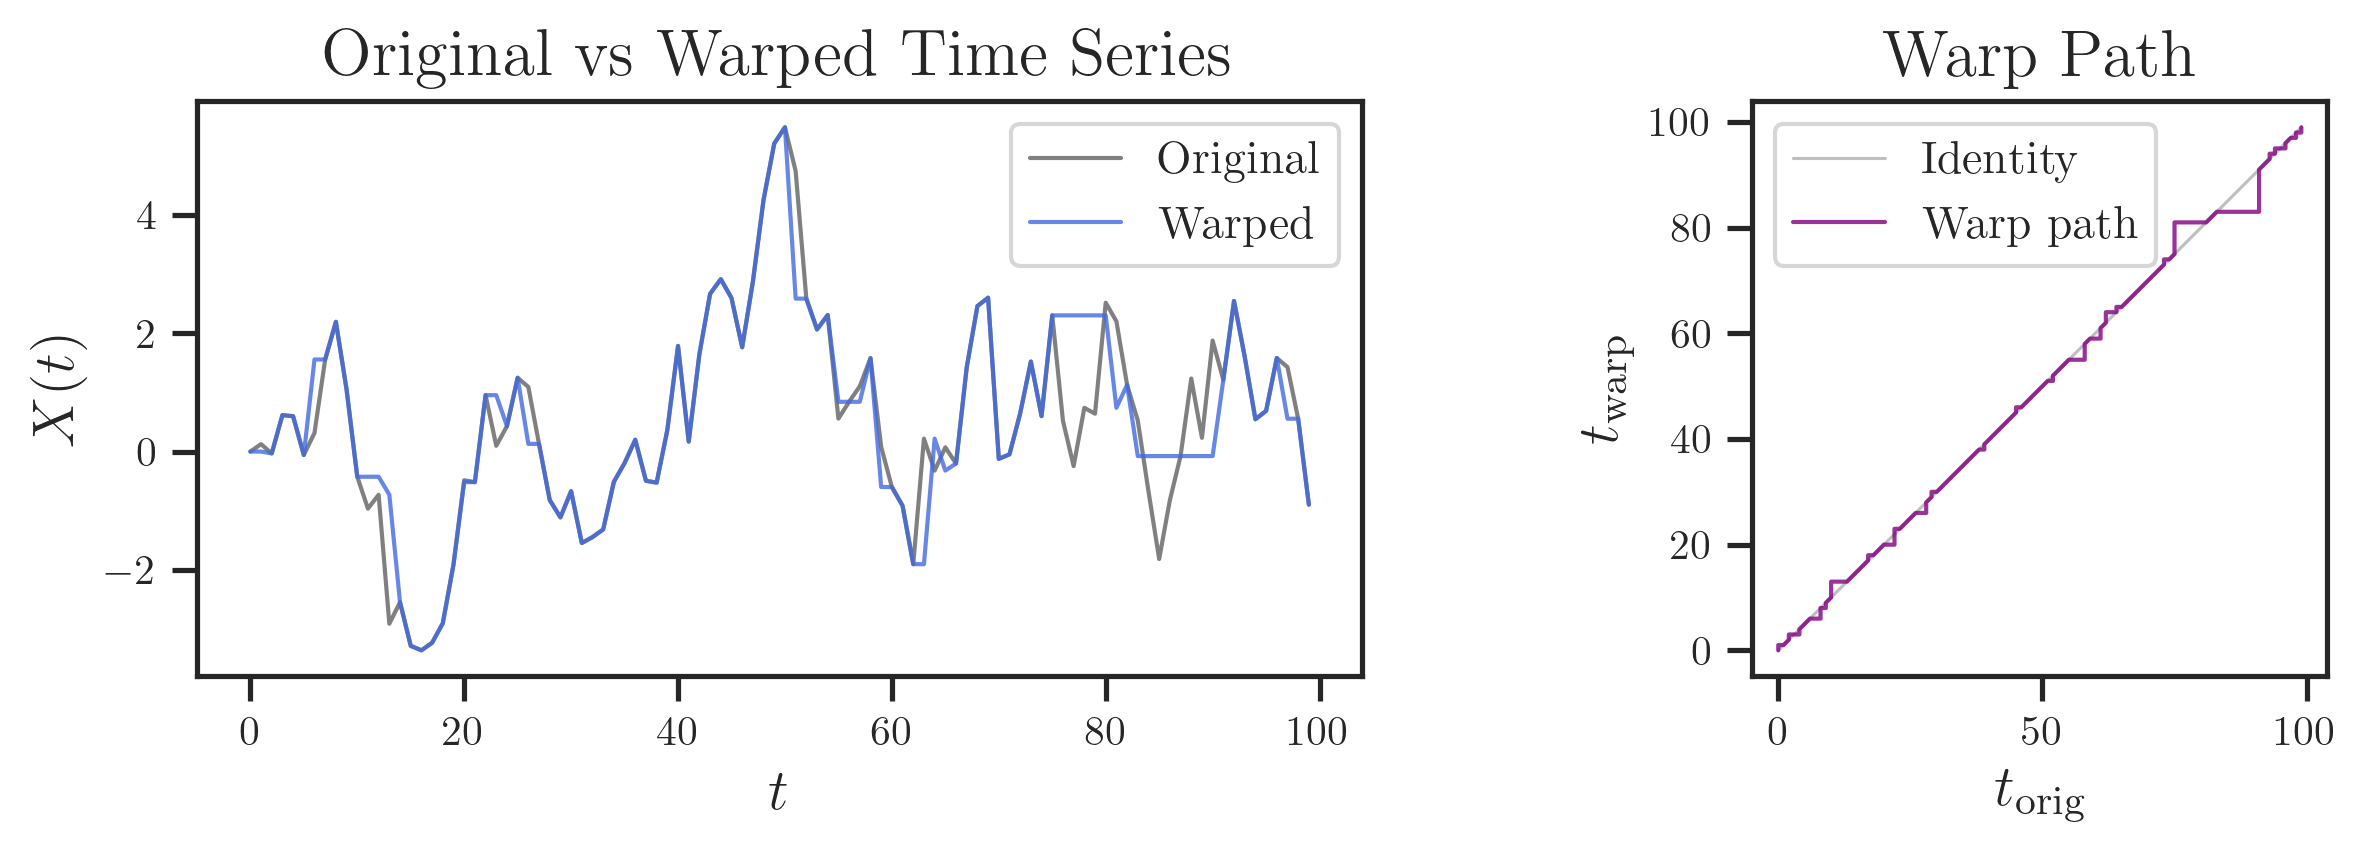

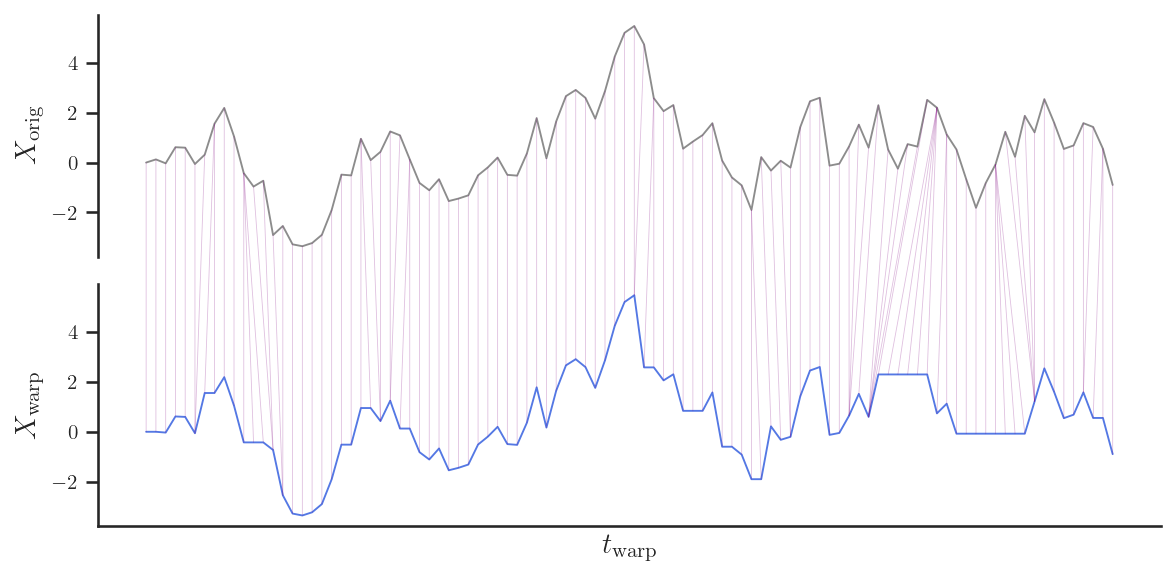

/var/folders/nq/8y70t4y10yb6nq4v5m7p_j340000gp/T/ipykernel_72516/2353045662.py:234: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


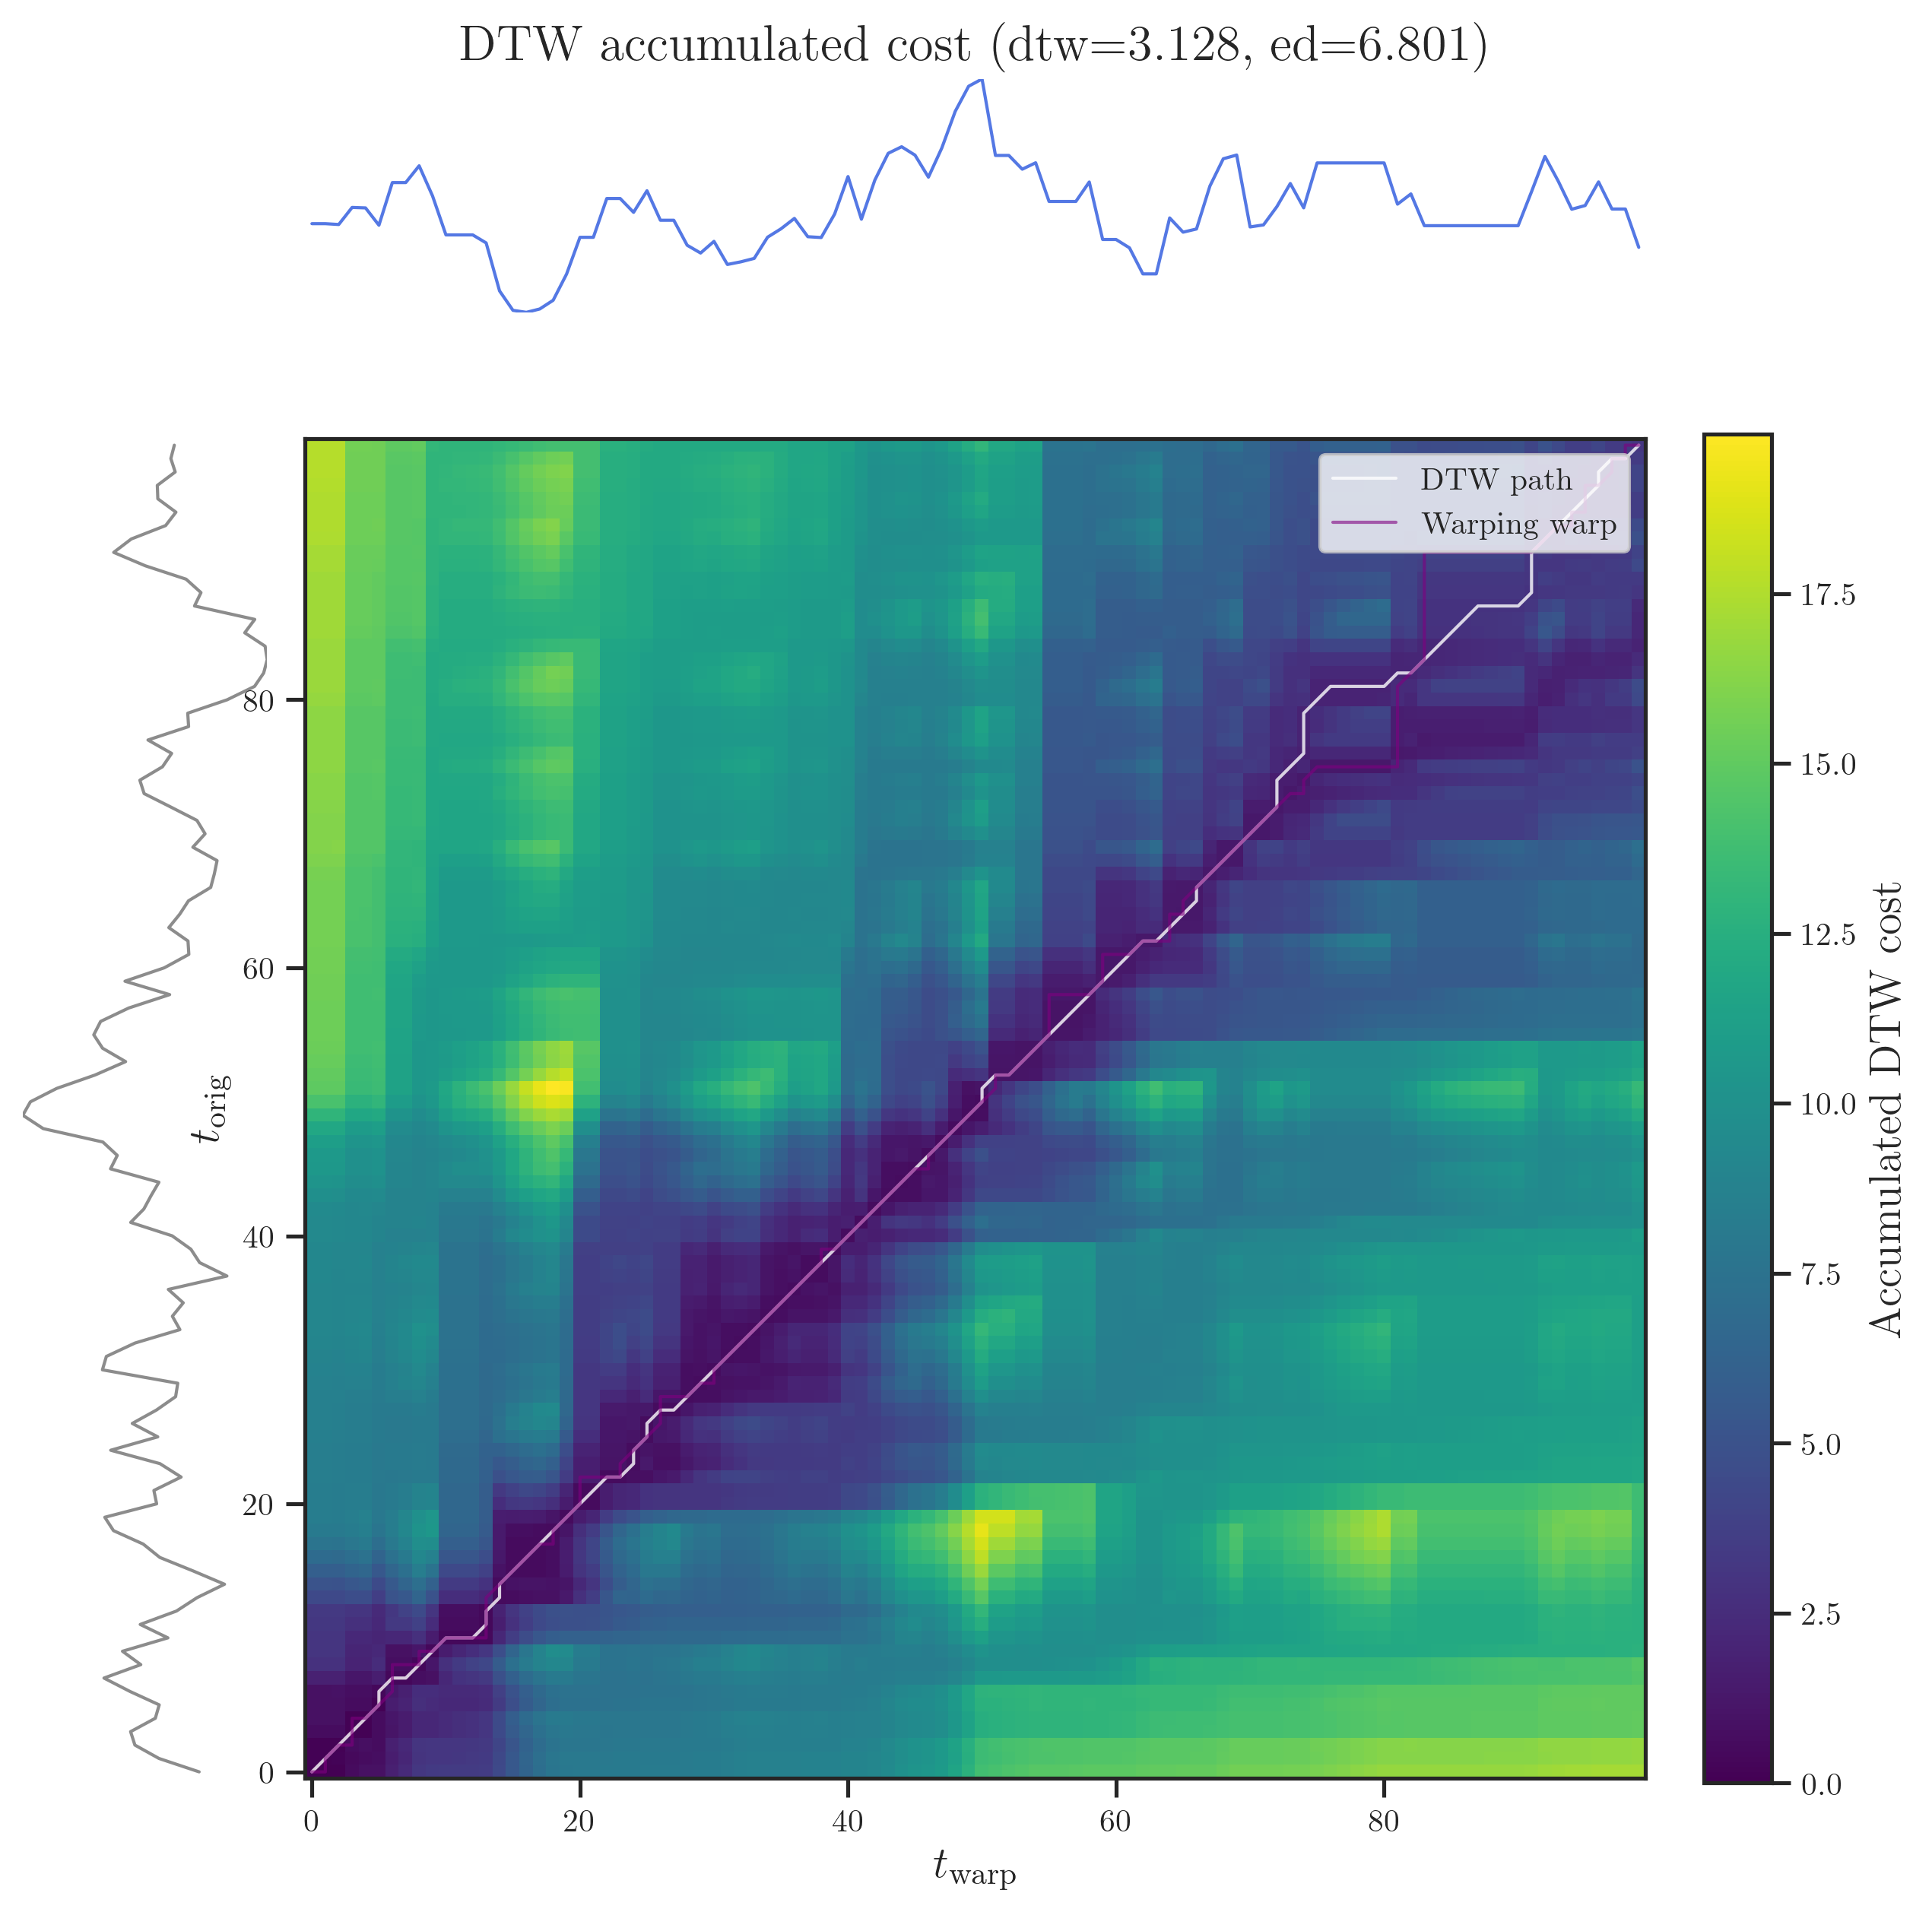

In [37]:
from matplotlib.ticker import ScalarFormatter
import numpy as np
import matplotlib.pyplot as plt
from dtaidistance import dtw, dtw_visualisation as dtwvis

if __name__ == "__main__":
    T = 100
    p = 0.5
    p_step = 0.3

    X = generate_ar1(T=T, a=0.8, noise_std=1.0, seed=0)
    euclidean_vals = []
    dtw_vals = []

    # path_true = warp_path(T=T, regime="geometric", p=p)
    path_true = warp_path(T=T, regime="rebound", p=p, p_step=p_step)
    mapping = path_to_mapping(path_true, T=T)
    X_warp = warp_series(X, mapping)

    ed = np.linalg.norm(X - X_warp)
    dtw_dist, paths, path_dtw = compute_dtw(X, X_warp, use_c=True)

    euclidean_vals.append(ed)
    dtw_vals.append(dtw_dist)

    print("Computed distances:")
    euclidean = np.linalg.norm(X - X_warp)  # pdist_euclidean
    print(f"pdist_euclidean:    {euclidean}")
    dtw_dist = dtw.distance(X, X_warp, use_c=True)
    print(f"dtw:                {dtw_dist}")
    dtw_sakoe_chiba = dtw.distance(X, X_warp, window=10, use_c=True)
    print(f"dtw_sakoe_chiba:    {dtw_sakoe_chiba}")

    plot_warp(X, X_warp, path_true, figsize=(9,3))
    fig_warp, axs_warp = plot_dtw_alignment(X, X_warp, path_dtw, figsize=(8,4))
    fig_paths, axes_paths = plot_dtw_warping_matrix(
        X, X_warp, paths,
        path=path_dtw,
        true_path=path_true,
        dtw_path_style={"color": "white", "linewidth": 1.0, "marker": "", "alpha": 0.8, "label": "DTW path"},
        true_path_style={"color": "purple", "linewidth": 1, "marker": "","alpha": 0.6, "label": "Warping warp"},
        orig_style={"color": "gray",      "linewidth": 1, "alpha": 0.9, "marker": ""},   # → left marginal
        warp_style={"color": "royalblue", "linewidth": 1, "alpha": 0.9, "marker": ""},   # → top marginal
        title=f"DTW accumulated cost (dtw={dtw_dist:.3f}, ed={ed:.3f})",
        # cmap=sns.dark_palette("#b1b4cc", as_cmap=True),
        cmap="viridis"
    )
    plt.show()



###### old plotting

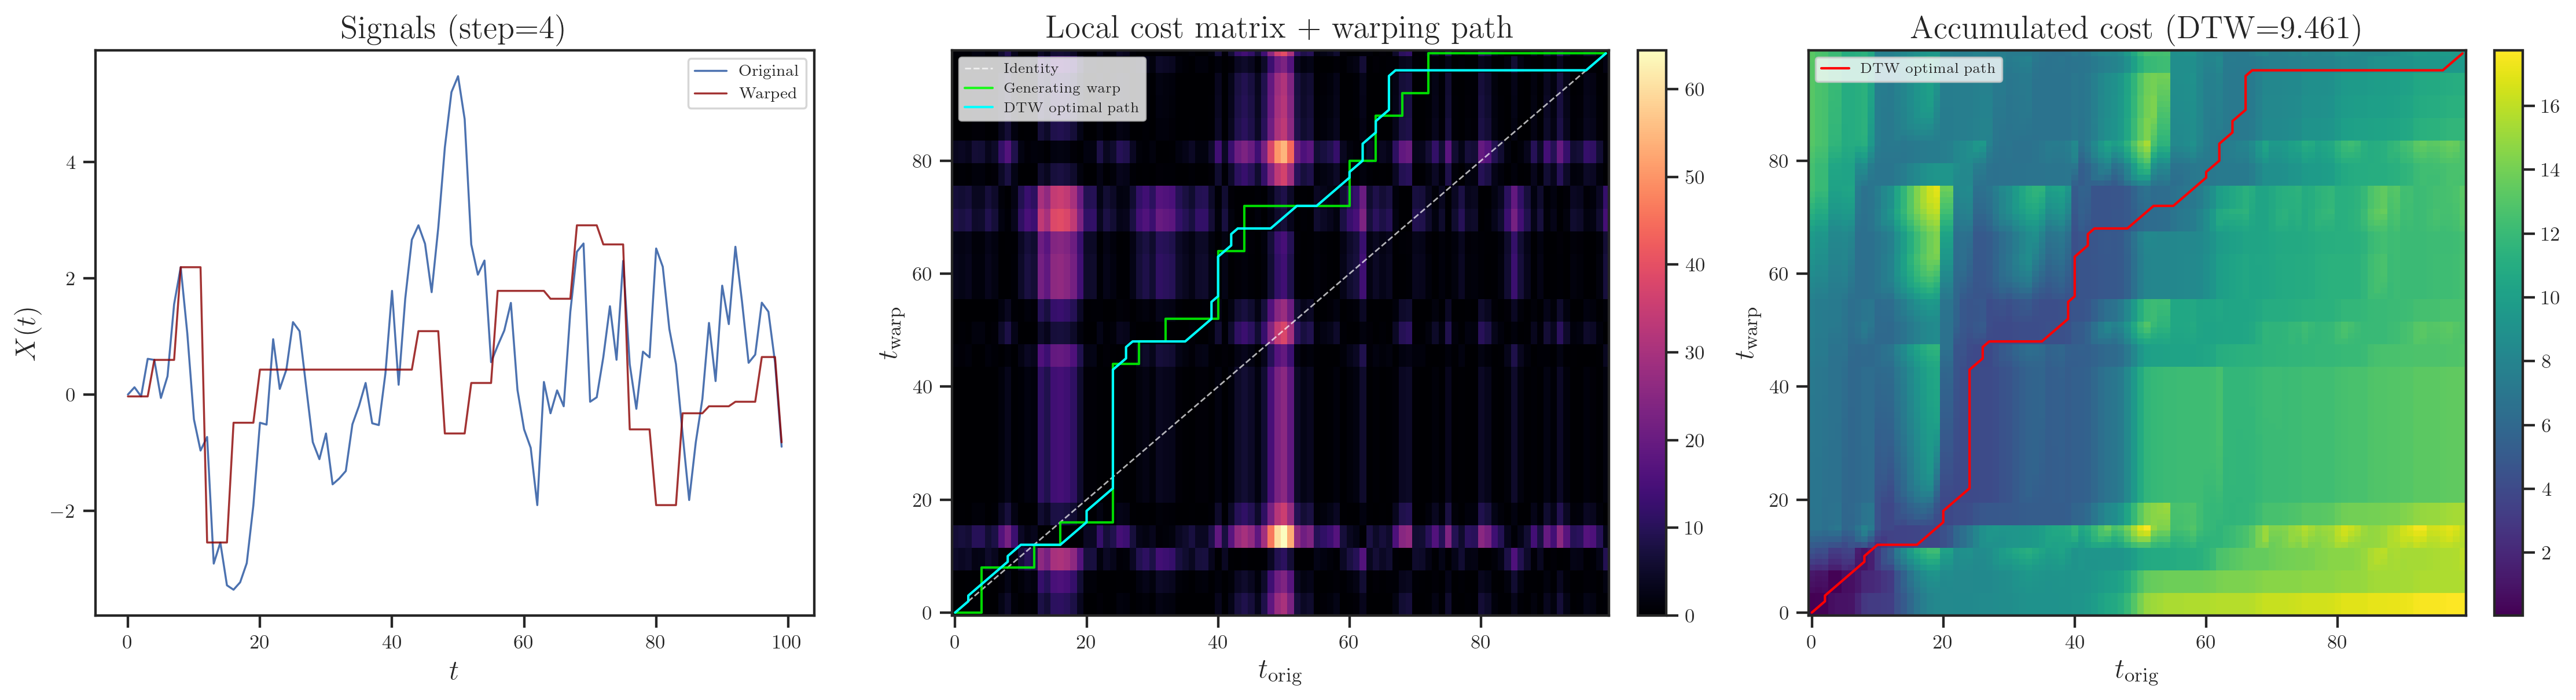

In [38]:
if __name__ == "__main__":
    T = 100
    step = 4

    X = generate_ar1(T=T, a=0.8, noise_std=1.0, seed=0)
    path_true = warp_path(T=T, regime="walk", step=step, seed=42)
    mapping = path_to_mapping(path_true, T=T)
    X_warp = warp_series(X, mapping)

    # Inferred DTW path between X and X_warp
    dtw_dist, accum_cost = dtw.warping_paths(X, X_warp, use_c=True)
    path_dtw = np.array(dtw.best_path(accum_cost), dtype=int)
    accum_cost_plot = accum_cost[1:, 1:]
    local_cost = (X[:, None] - X_warp[None, :]) ** 2

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=250)

    # Panel 1: time series
    ax = axes[0]
    ax.plot(X, label="Original", lw=1.0)
    ax.plot(X_warp, label="Warped", lw=1.0, alpha=0.8, color="darkred")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$X(t)$")
    ax.set_title(f"Signals (step={step})")
    ax.legend(loc="upper right", fontsize=8)

    # Panel 2: classic local cost matrix + paths
    ax = axes[1]
    im1 = ax.imshow(local_cost.T, origin="lower", aspect="auto", cmap="magma")
    ax.plot([0, T - 1], [0, T - 1], "w--", lw=0.8, alpha=0.7, label="Identity")
    ax.plot(path_true[:, 0], path_true[:, 1], color="lime", lw=1.2, alpha=0.85, label="Generating warp")
    ax.plot(path_dtw[:, 0], path_dtw[:, 1], color="cyan", lw=1.2, label="DTW optimal path")
    ax.set_xlabel(rf"$t_{{\mathrm{{orig}}}}$")
    ax.set_ylabel(rf"$t_{{\mathrm{{warp}}}}$")
    ax.set_title("Local cost matrix + warping path")
    ax.legend(loc="upper left", fontsize=7)
    fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

    # Panel 3: accumulated cost matrix + DTW path
    ax = axes[2]
    im2 = ax.imshow(accum_cost_plot.T, origin="lower", aspect="auto", cmap="viridis")
    ax.plot(path_dtw[:, 0], path_dtw[:, 1], color="red", lw=1.2, label="DTW optimal path")
    ax.set_xlabel(rf"$t_{{\mathrm{{orig}}}}$")
    ax.set_ylabel(rf"$t_{{\mathrm{{warp}}}}$")
    ax.set_title(f"Accumulated cost (DTW={dtw_dist:.3f})")
    ax.legend(loc="upper left", fontsize=7)
    fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()


###### old DTW Viz

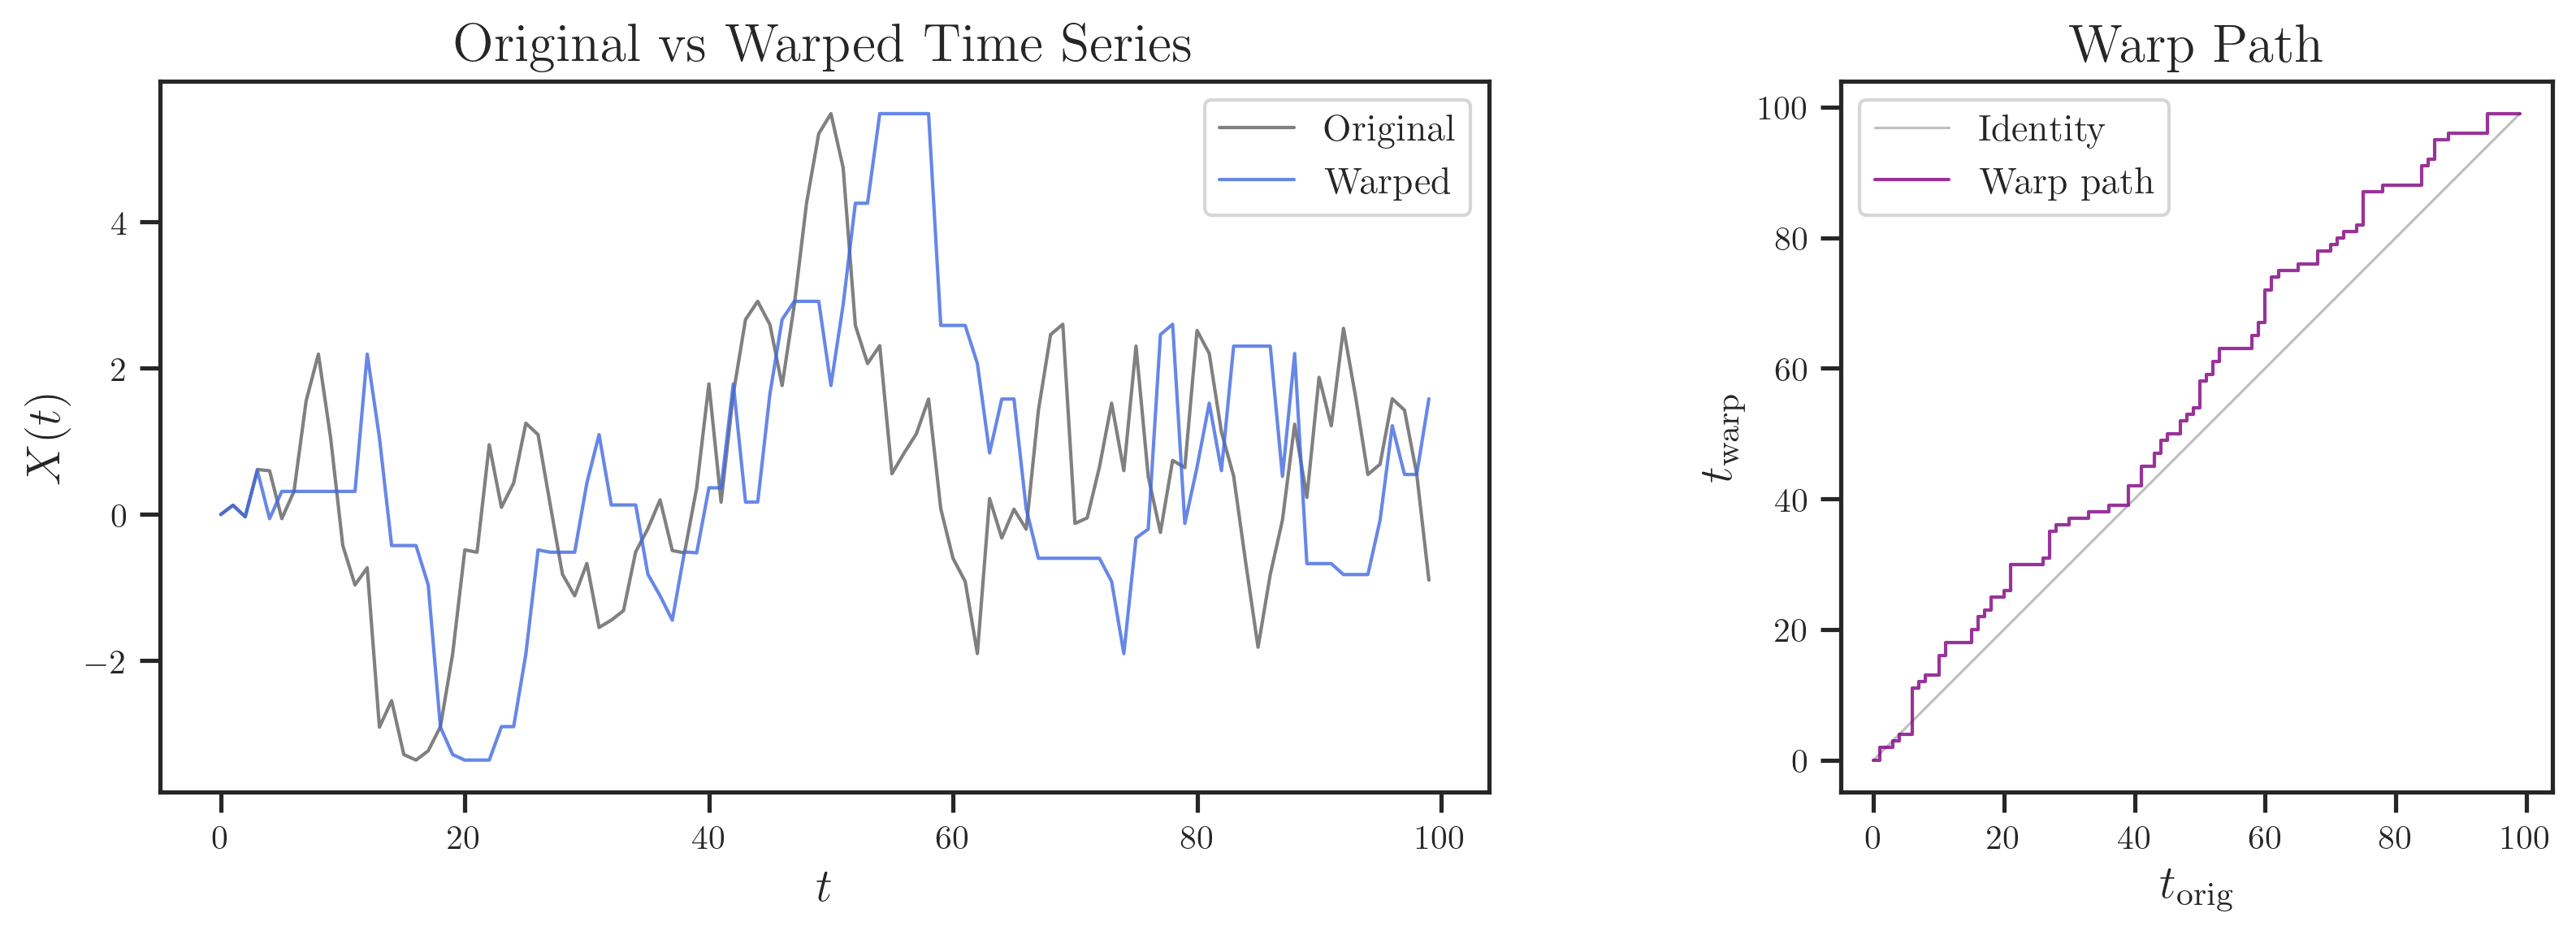

In [39]:
if __name__ == "__main__":
    T = 100
    step = 1

    X = generate_ar1(T=T, a=0.8, noise_std=1.0, seed=0)
    path = warp_path(T=T, regime="walk", step=step, seed=42)
    mapping = path_to_mapping(path, T=T)
    X_warp = warp_series(X, mapping)

    fig, axes = plot_warp(X, X_warp, path)


#### --- divider ---

#### Making the MTS generator

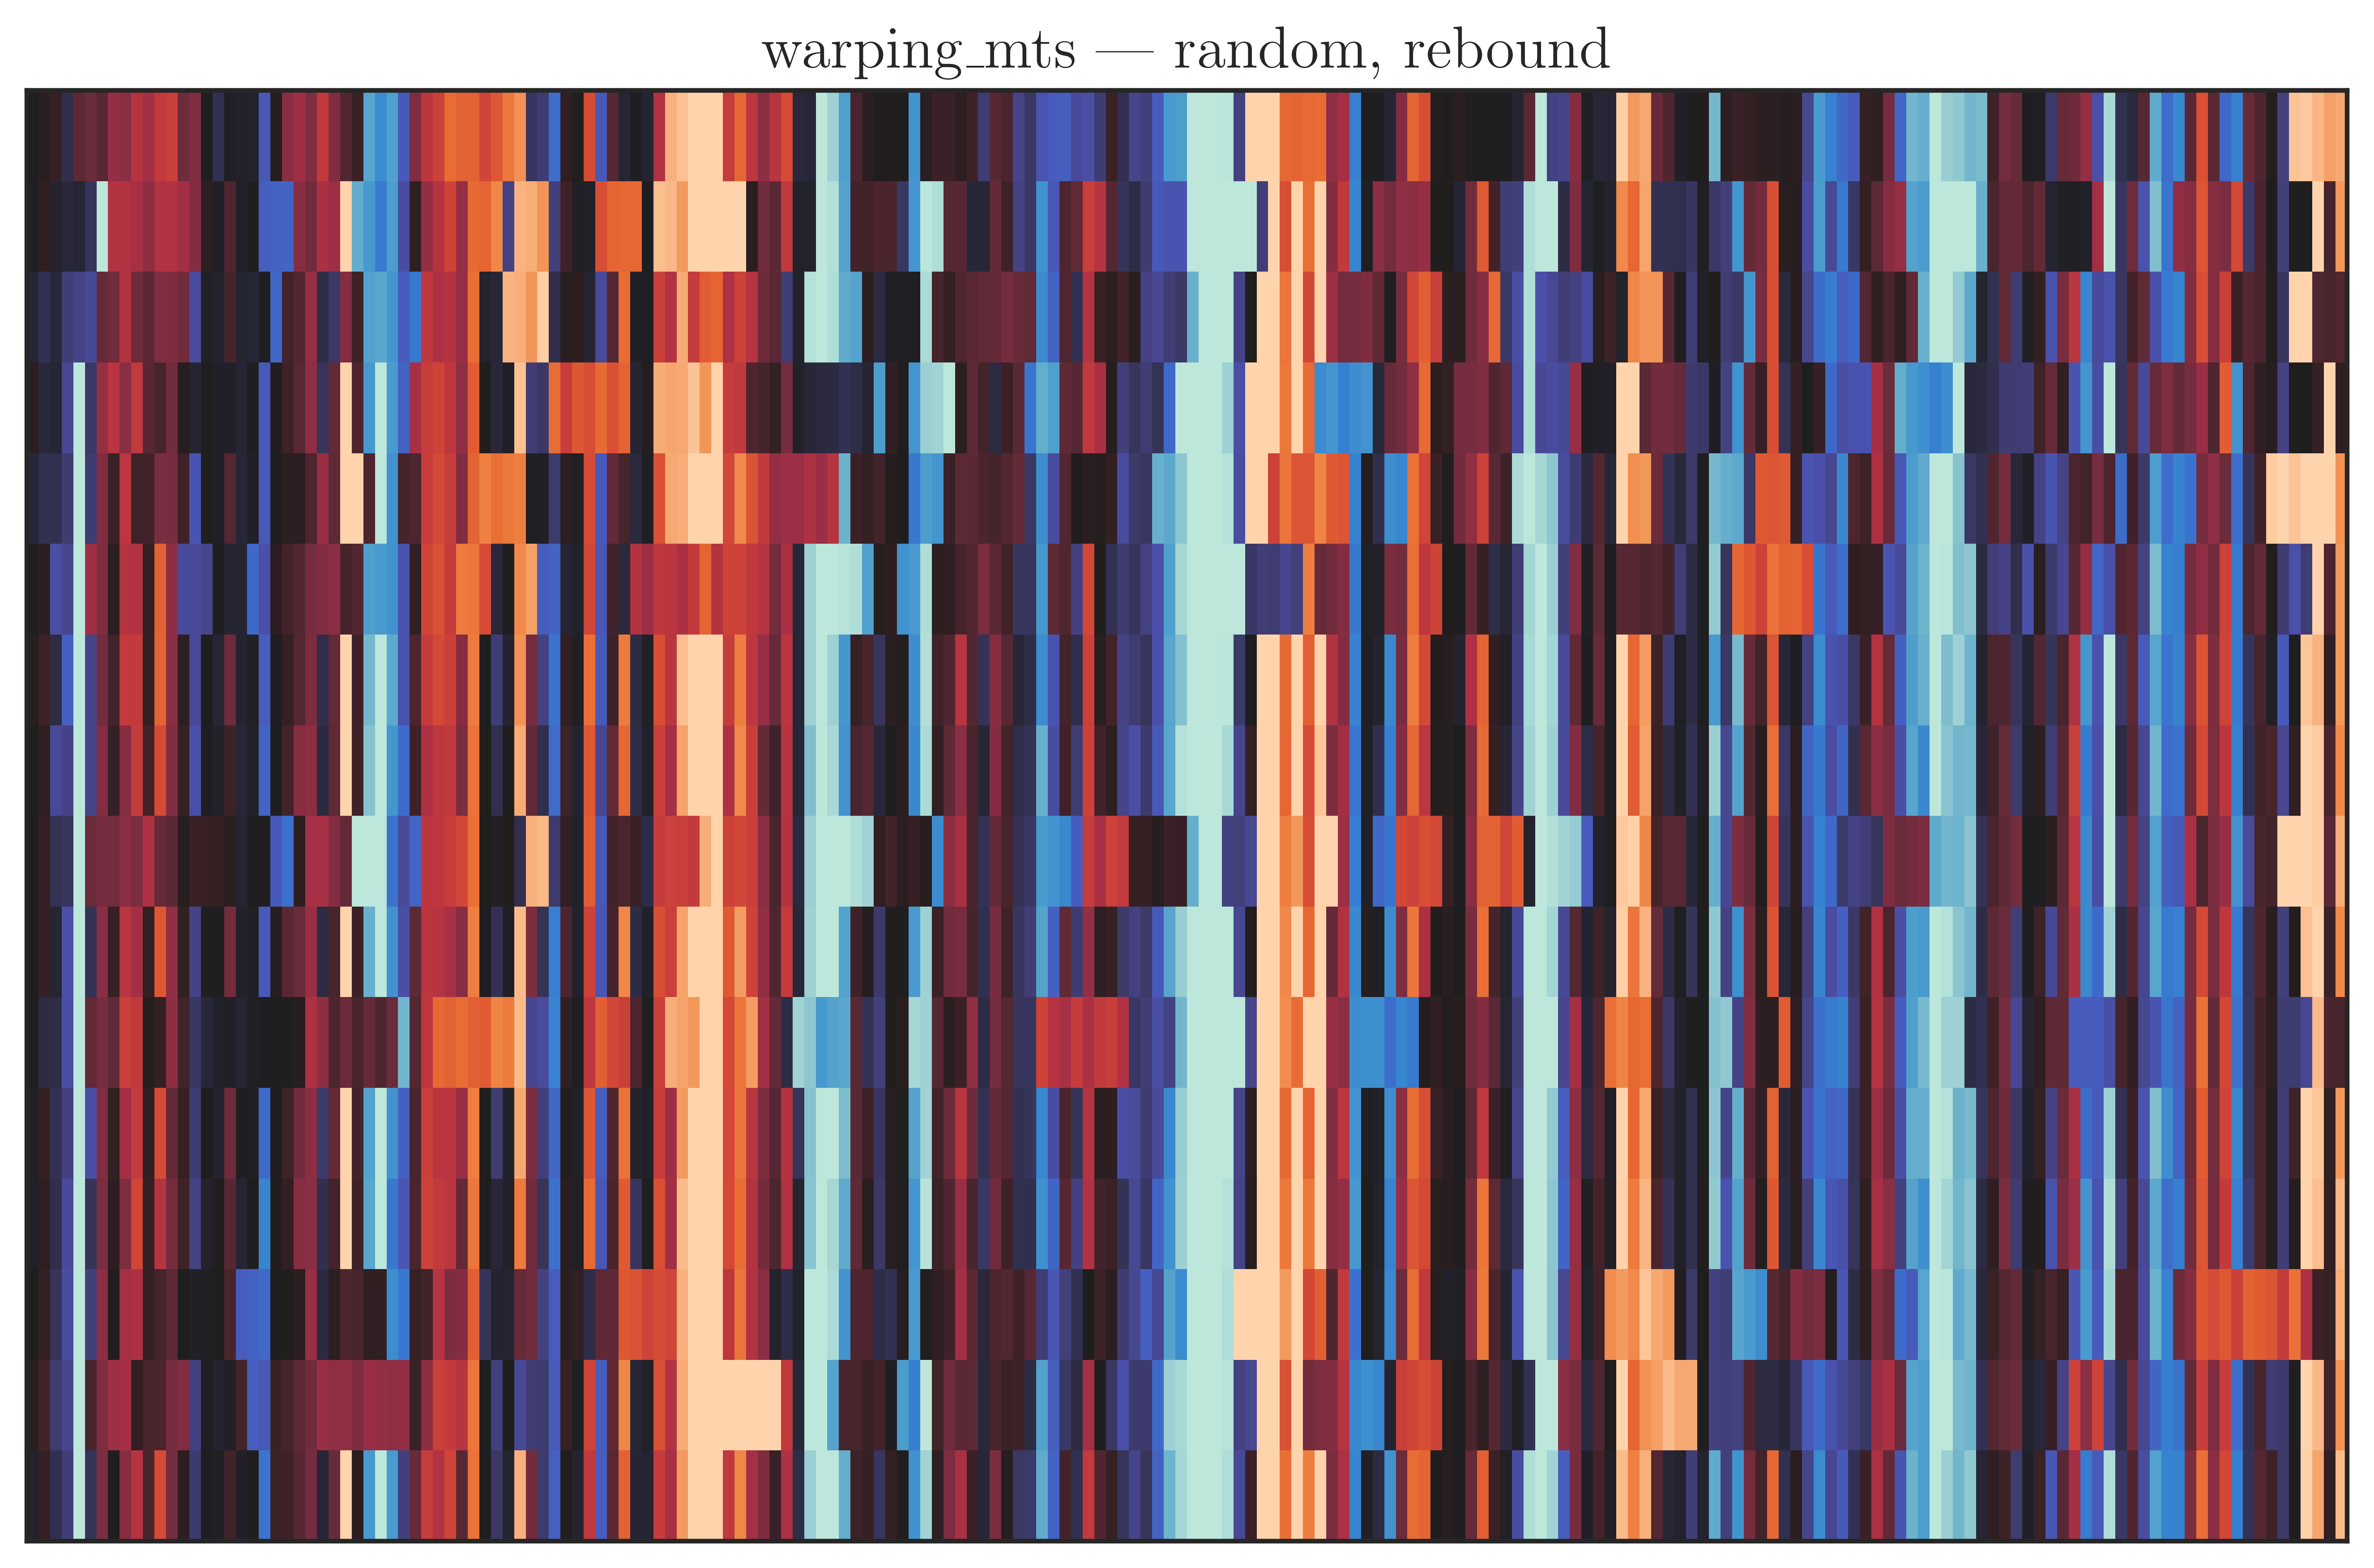

In [49]:
from src.generators import generate_warping_mts

M, T = 16, 200
ar1_a, ar1_noise_std = 0.8, 1.0
n_noisy, n_warped = 4, 4
warping_regime = "rebound"
warp_p, warp_p_step = 0.5, 0.4
noise_std = 0.1

X_random = generate_warping_mts(
    M=M, T=T,
    regime="random",
    warping_regime=warping_regime, warp_p=warp_p,
    noise_std=noise_std, ar1_a=ar1_a, ar1_noise_std=ar1_noise_std,
    _regime_seed=42, rng=2,
)
plot_mts_heatmap(X_random, title=f"warping_mts — random, {warping_regime}", vmin=-2, vmax=2)

